- data 폴더 안 `bodyPerformance.csv` 파일 로드
- 데이터 중 dtypes가 `object`인 데이터는 `LabelEncoder`를 사용
- 독립, 종속 변수 데이터 분할
- train, test, 8:2 비율로 분할
- 독립 데이터들은 `StandardScaler`를 이용하여 스케일링
- Target Class의 개수만큼 Linear 모델에서 output 출력을 설정하는 모델을 생성
- 손실함수는 `CrossEntropy` 사용
- optimizer는 `Adam` 사용
- 최종 예측 값을 이용하여 성능 평가

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv('../data/bodyPerformance.csv')
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [6]:
le = LabelEncoder()
obj_cols = df.select_dtypes('object').columns

for col in obj_cols:
    df[col] = le.fit_transform(df[col])

df.head(3)

C:\Users\hkssn\AppData\Local\Temp\ipykernel_15844\1638694140.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes('object').columns


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2


In [7]:
X = df.drop('class', axis = 1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [10]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [12]:
class body_clf(nn.Module):
    def __init__(self, _dim):
        super(body_clf, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim*3),
            nn.ReLU(),
            nn.Linear(_dim*3, _dim*2),
            nn.ReLU(),
            nn.Linear(_dim*2, 4)
        )
    
    def forward(self, x):
        return self.model(x)

In [13]:
body_model = body_clf(X_test_tensor.shape[1])

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(body_model.parameters(), lr=0.001)
    # Adam에서 lr은 학습률의 상한

In [15]:
body_model.train()

for epoch in range(200):
    pred = body_model(X_train_tensor)
    loss = criterion(pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1)%20 == 0:
        print(f'Epoch {epoch+1}, Loss: {round(loss.item(), 6)}')

Epoch 20, Loss: 1.365146
Epoch 40, Loss: 1.305585
Epoch 60, Loss: 1.192026
Epoch 80, Loss: 1.057674
Epoch 100, Loss: 0.95843
Epoch 120, Loss: 0.898128
Epoch 140, Loss: 0.866871
Epoch 160, Loss: 0.849031
Epoch 180, Loss: 0.83671
Epoch 200, Loss: 0.827628


In [16]:
body_model.eval()

with torch.no_grad():
    pred = body_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    acc = accuracy_score(y_test_tensor, pred_idx)
    print(f'Test Accuracy: {round(acc, 4)}')
    print(classification_report(y_test_tensor, pred_idx))

Test Accuracy: 0.6379
              precision    recall  f1-score   support

           0       0.65      0.78      0.71       670
           1       0.49      0.48      0.49       669
           2       0.59      0.52      0.55       670
           3       0.82      0.76      0.79       670

    accuracy                           0.64      2679
   macro avg       0.64      0.64      0.64      2679
weighted avg       0.64      0.64      0.64      2679



In [17]:
import matplotlib.pyplot as plt

In [38]:
# 선형 모델
linear_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Linear(64, 1)
)

In [39]:
relu_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [40]:
loss = nn.MSELoss()
optimizer_linear = optim.Adam(linear_model.parameters(), lr=0.01)
optimizer_relu = optim.Adam(relu_model.parameters(), lr = 0.01)

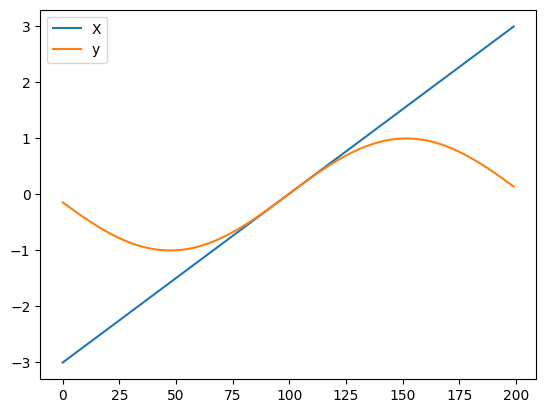

In [41]:
X = torch.linspace(-3, 3, 200).unsqueeze(1)
y = torch.sin(X)

plt.plot(X, label='X')
plt.plot(y, label='y')
plt.legend()
plt.show()

In [42]:
for epoch in range(3000):
    pred1 = linear_model(X)
    loss1 = loss(pred1, y)
    optimizer_linear.zero_grad()
    loss1.backward()
    optimizer_linear.step()

    pred2 = relu_model(X)
    loss2 = loss(pred2, y)
    optimizer_relu.zero_grad()
    loss2.backward()
    optimizer_relu.step()

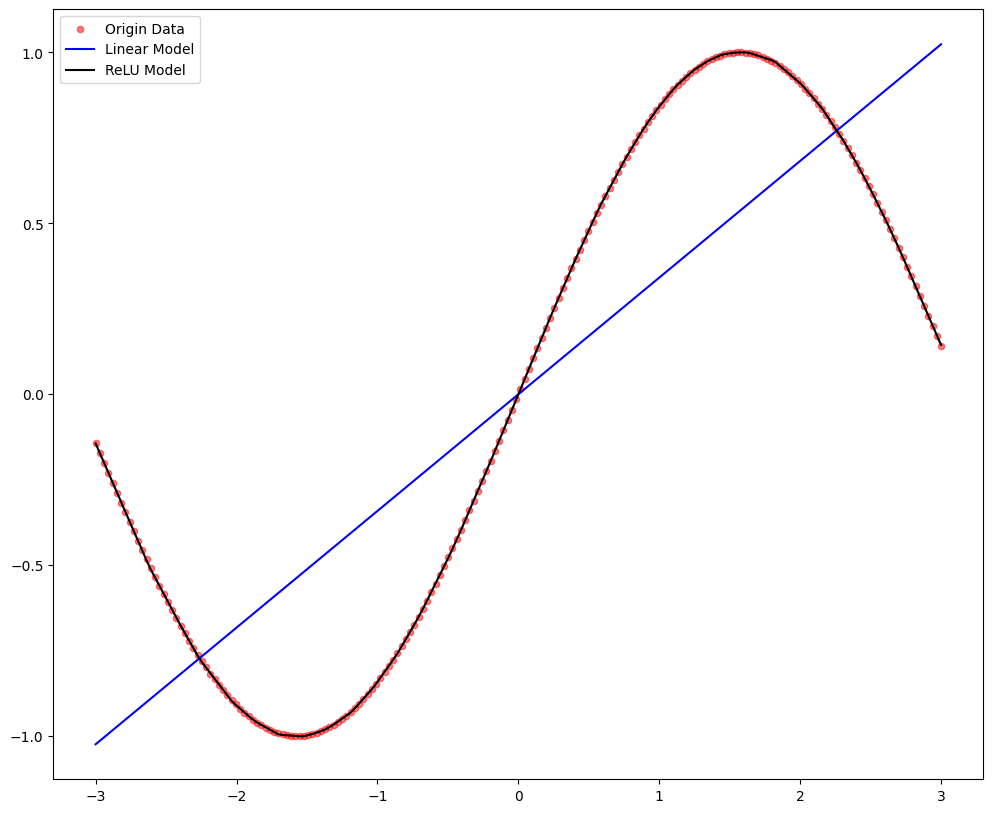

In [43]:
# detach(): 예측의 결과는 결과값 + 가중치 함수 데이터가 포함되어있어, detach()로 결과값만 가져온다.

linear_pred = linear_model(X).detach()
relu_pred = relu_model(X).detach()

plt.figure(figsize = (12, 10))
# 원본 데이터
plt.scatter(X, y, label = 'Origin Data', s = 20, color='red', alpha = 0.5)
# 선형 모델
plt.plot(X, linear_pred, label = 'Linear Model', color = 'blue')
# 비선형 모델
plt.plot(X, relu_pred, label = 'ReLU Model', color = 'black')
plt.legend()
plt.show()